# Project 2 
## Code & Report
## Date: 

## Group 1
## Esja Kristín Siggeirsdóttir, Eyþór Trausti Óskarsson

In [ ]:
# types of possible plots
# scatterplot - could use it to show different phonemes prediction? Different colors and sizes of the dots in the plot
# boxplot
# barplot
# strip plot
# joint plot - combined plot - hex plots
# pairplot
# heatmap
# clustermap

# What we are using so far: 
# confusion matrix
# classification report
# histogram

# Goal: You will evaluate how well your HMM predicts phoneme sequences from the speech signal.
# so we predict the phoneme sequences given the audio files
# and then we compare the predicted sequences to the actual labels in the audio files

In [396]:
# IMPORTS TODO: remove this line later

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Model Description

Exact definition of the state space (phoneme set) and observation model,
- Pau is mapped to int 0 - why did we do that again?
- Phoneme set is sorted alphabetically and mapped to integers
- Each phoneme label is mapped to a frame in the feature matrix

Transition, emission, and initial distributions.

# Task 6.1
## Data preparation: Align feature frames with phonetic labels to create supervised training data

For each audio sample we have
O1:T = feature vectors (from .npy)
X1:T = phoneme labels (integers)

In [397]:
# Load the feature matrices (e.g. using numpy.load("arctic_a0001.npy")) as the observation sequences O1:T , - MISSING???
# Align each frame to a phoneme label (from the corresponding .lab file) to obtain the state sequence X1:T for supervised training,
# Use these feature matrices throughout training, inference, and evaluation.

# paths to data
SPLITS_AND_FEATURES_DIR = "data/out/"
LABEL_DIR = "data/cmu_us_slt_arctic/lab/"

def make_basenames(split_file):
    """Read train.txt, val.txt, and test.txt to obtain basenames for each split."""
    with open(split_file, "r") as file:
        basenames = [line.strip() for line in file]
    return basenames

# Load files as lists
train_ids = make_basenames(os.path.join(SPLITS_AND_FEATURES_DIR, "train.txt"))
test_ids = make_basenames(os.path.join(SPLITS_AND_FEATURES_DIR, "test.txt"))
val_ids = make_basenames(os.path.join(SPLITS_AND_FEATURES_DIR, "val.txt"))

def load_label_file(basename):
    """Create a phoneme set and a mapping from phoneme labels to integer indices"""
    label_path = os.path.join(LABEL_DIR, basename + ".lab")
    segments = []
    with open(label_path, "r") as file:
        next(file)  # skip the header of each file, its "#"
        for line in file:
            parts = line.strip().split()

            timestamp = float(parts[0])
            phoneme = parts[2]

            segments.append((timestamp, phoneme))

    return segments


def extract_phoneme_set(basenames):
    phonemes = set()

    for basename in basenames:
        segments = load_label_file(basename)
        for _, ph in segments:
            phonemes.add(ph)

    # pau set to index 0 
    sorted_list = sorted(list(phonemes))
    sorted_list.remove("pau")
    sorted_list.insert(0, "pau")
    return sorted_list

phoneme_set = extract_phoneme_set(train_ids)  
phoneme_to_idx = {p: i for i, p in enumerate(phoneme_set)} # PHONEMES TO INTS? - PHONEME BASED STATE SPACE TODO: is this correct?
idx_to_phoneme = {i: p for p, i in phoneme_to_idx.items()}
print("The Phoneme set", phoneme_set)
print("Phoneme set to ints", phoneme_to_idx)  # 40 phonemes mapped to an int + pau = 41 phonemes in total
print("Ints to phonemes", idx_to_phoneme)

# Load feature files
def load_feature_matrix(basename):
    """
    (T, D)
    T = number of frames
    D = feature dimension (always 39?)
    """
    feature_path = os.path.join(SPLITS_AND_FEATURES_DIR, basename + ".npy")
    features = np.load(feature_path)
    return features

# Convert time stamps -> assign each phoneme label a frame
# These timestamps represent when the phoneme becomes active.
# Example: frames between t0 and t1 → phoneme0

def align_frames_to_phonemes(features, segments, phoneme_to_idx, frame_shift=0.01):
    """ ræ ræ ræ"""
    T = features.shape[0]
    labels = np.zeros(T, dtype=int)

    for i in range(len(segments)):

        start_time, phoneme = segments[i]

        # if i < len(segments) - 1:
        #     end_time = segments[i + 1][0]
        # else:
        #     end_time = T * frame_shift

        # So the last phoneme doesn't sometimes extend past the last frame.
        if i < len(segments) - 1:
            end_time = int(segments[i + 1][0] / frame_shift)
        else:
            end_time = T

        start_frame = int(start_time / frame_shift)
        end_frame = int(end_time / frame_shift)

        start_frame = max(0, start_frame)
        end_frame = min(T, end_frame)

        labels[start_frame:end_frame] = phoneme_to_idx[phoneme]

    return labels

def process_audio_sample(basename):
    """Combine features and labels"""
    features = load_feature_matrix(basename)
    segments = load_label_file(basename)

    labels = align_frames_to_phonemes(features, segments, phoneme_to_idx)

    assert len(labels) == features.shape[0]

    return features, labels 

features, labels = process_audio_sample(train_ids[0])

def build_dataset(basenames):
    """Apply it to the train.txt set"""
    dataset = []

    for basename in basenames:
        features, labels = process_audio_sample(basename)
        dataset.append((features, labels))

    return dataset  # Each audio becomes (features: T×39, labels: T)

train_data = build_dataset(train_ids) # ATH - the data we will be using from on here as the aligned training data!
val_data = build_dataset(val_ids)
test_data = build_dataset(test_ids)

The Phoneme set ['pau', 'aa', 'ae', 'ah', 'ao', 'aw', 'ax', 'ay', 'b', 'ch', 'd', 'dh', 'eh', 'er', 'ey', 'f', 'g', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z', 'zh']
Phoneme set to ints {'pau': 0, 'aa': 1, 'ae': 2, 'ah': 3, 'ao': 4, 'aw': 5, 'ax': 6, 'ay': 7, 'b': 8, 'ch': 9, 'd': 10, 'dh': 11, 'eh': 12, 'er': 13, 'ey': 14, 'f': 15, 'g': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'r': 29, 's': 30, 'sh': 31, 't': 32, 'th': 33, 'uh': 34, 'uw': 35, 'v': 36, 'w': 37, 'y': 38, 'z': 39, 'zh': 40}
Ints to phonemes {0: 'pau', 1: 'aa', 2: 'ae', 3: 'ah', 4: 'ao', 5: 'aw', 6: 'ax', 7: 'ay', 8: 'b', 9: 'ch', 10: 'd', 11: 'dh', 12: 'eh', 13: 'er', 14: 'ey', 15: 'f', 16: 'g', 17: 'hh', 18: 'ih', 19: 'iy', 20: 'jh', 21: 'k', 22: 'l', 23: 'm', 24: 'n', 25: 'ng', 26: 'ow', 27: 'oy', 28: 'p', 29: 'r', 30: 's', 31: 'sh', 32: 't', 33: 'th', 34: 'uh',

In [398]:
# Printing the data
print("\n")

print("Example of feature tuple")
features = load_feature_matrix("arctic_a0001")
print("Shape of feature matrix", features.shape)

print("\n")

# equal so data is ready for HMM training! Yibby :D
print("Feature frames:", features.shape[0])
print("Phoneme labels:", len(labels))

print("\n")

print("Split loading check: ")
print("Train utterances:", len(train_data))
print("Validation utterances:", len(val_data))
print("Test utterances:", len(test_data))

print("\n")





Example of feature tuple
Shape of feature matrix (334, 39)


Feature frames: 334
Phoneme labels: 401


Split loading check: 
Train utterances: 792
Validation utterances: 113
Test utterances: 227




In [399]:
print("Inspect one full sample of phoneme labels and feature vectors: ")
features, labels = train_data[0]

# T = 401 frames
# D = 39 features per frame
print("Feature shape:", features.shape)
print("Label shape:", labels.shape)

# Each feature fector equals 39
print("First 2 feature vectors:")
print(features[:2])

# A good sign that each phoneme appears multiple times in a row
print("First 100 labels:")
print(labels[:100])


Inspect one full sample of phoneme labels and feature vectors: 
Feature shape: (401, 39)
Label shape: (401,)
First 2 feature vectors:
[[ 8.44829266e+00 -1.73106664e+01  1.17692710e+01  1.31655014e+01
   1.31785167e+01  1.37866798e+01  6.19260236e+00  1.11669040e+01
   7.20270514e+00  4.55176572e+00  2.58423327e+00  5.26122987e+00
  -6.26104591e+00 -3.44203938e-02 -6.99613830e-01 -3.88447808e-01
  -9.65014132e-01  3.52442602e-01  2.59351866e-01  2.81647174e+00
   7.95274315e-02  1.87742094e-01  6.23042230e-01 -1.10321648e+00
  -2.21079250e+00 -8.92766793e-01 -2.66872826e-04 -1.44365601e-01
  -3.22404258e-01 -6.24036915e-02 -3.38574459e-01 -7.87111729e-02
  -4.53598682e-01 -1.46899688e-01  5.15724038e-01  3.26040791e-01
  -6.75031552e-02 -5.29157569e-01  2.59442539e-01]
 [ 8.35227755e+00 -1.90200543e+01  1.24895740e+01  1.23516802e+01
   1.63859363e+01  1.28333922e+01  1.49954633e+01  1.22797337e+01
   2.80712934e+00  1.03414693e+00 -8.25670262e-01  5.80330083e+00
  -4.98977552e+00 -4.65

In [400]:
print("Checking phoneme distribution")
all_labels = np.concatenate([y for _, y in train_data])

counts = np.bincount(all_labels)

# phoneme distribution for ALL the phonemes
# for idx in np.argsort(counts)[::-1][:41]:
#     print(idx_to_phoneme[idx], counts[idx])

sorted_indices = np.argsort(counts)

# top 5 most frequent phonemes
print("Top 5 most frequent phonemes:")
for idx in sorted_indices[::-1][:5]:
    print(idx_to_phoneme[idx], counts[idx])

print("\n5 least frequent phonemes:")
for idx in sorted_indices[:5]:
    print(idx_to_phoneme[idx], counts[idx])

Checking phoneme distribution
Top 5 most frequent phonemes:
pau 22638
ax 16951
n 14487
ih 13834
t 13365

5 least frequent phonemes:
zh 248
oy 635
uh 1140
ch 1354
jh 1462


# Task 6.2
# Supervised estimation: estimate HMM parameters (initial distribution, transition matrix, state emission parameters)

Explanation...
After this the model is HMM with Gaussian emissions

In [401]:
# initial distribution
initial_dict = {}

for data in train_data:
    num = int(data[1][0])
    if num in initial_dict.keys():
        initial_dict[num] += 1
    else:
        initial_dict[num] = 1

# normalize to probabilities
pi = np.zeros(len(phoneme_set))

for k, v in initial_dict.items():
    pi[k] = v

pi = pi / np.sum(pi)

print("initital distribution:", pi)
print("Sum of pi:", np.sum(pi))

initital distribution: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sum of pi: 1.0


Tran matrix A: [[9.55044455e-01 3.17546770e-04 2.58573766e-03 ... 1.31555076e-03
  9.07276808e-05 4.53638177e-11]
 [4.27441971e-04 8.79888858e-01 2.13721092e-04 ... 2.13720879e-10
  3.26992946e-02 6.41162850e-04]
 [1.90114067e-10 1.90114067e-10 8.38212921e-01 ... 1.90114067e-10
  7.60456287e-03 3.80228324e-04]
 ...
 [6.63129955e-10 6.63130619e-04 6.63130619e-04 ... 8.66710852e-01
  6.63129955e-10 6.63129955e-10]
 [1.09557991e-02 1.88893104e-03 6.23347200e-03 ... 1.51114487e-03
  8.69474871e-01 1.88893085e-10]
 [8.06451883e-03 4.03226143e-03 4.03225740e-09 ... 4.03225740e-09
  4.03225740e-09 8.83064374e-01]]
Row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Max row sum error: 5.551115123125783e-16


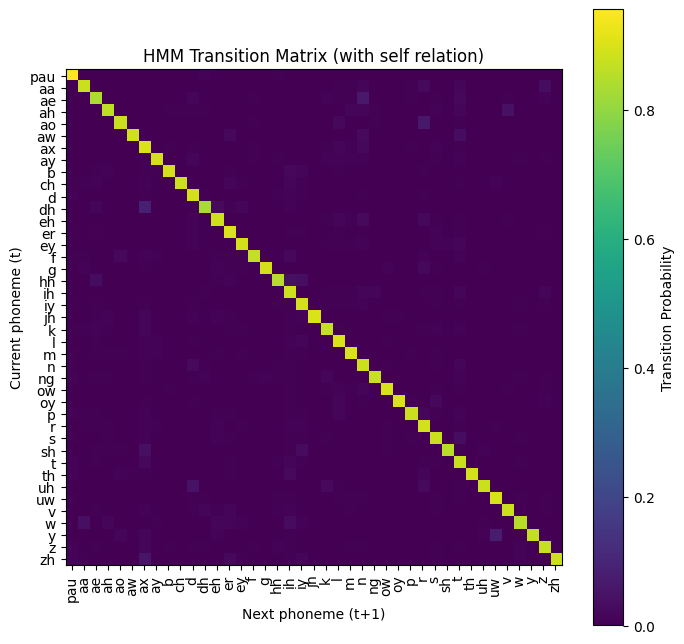

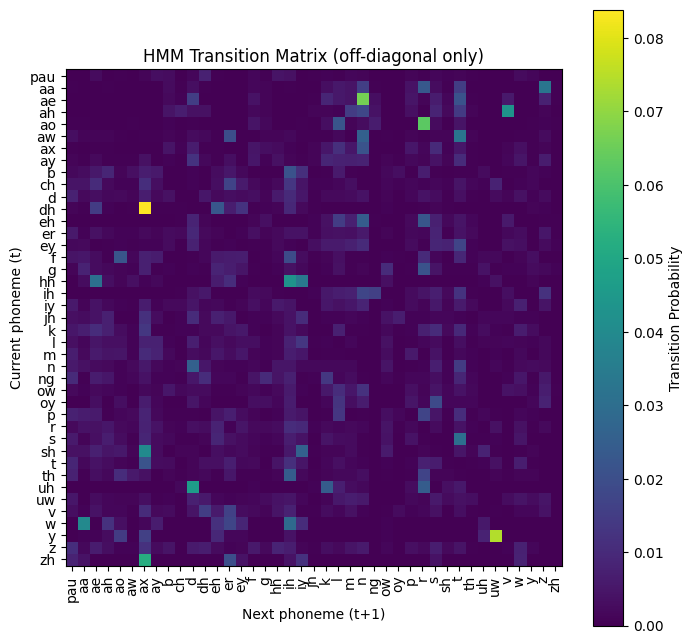

In [402]:
# transition matrix
transition_dict = {}
instances_dict = {}

for data in train_data:
    labels = data[1]
    for i in range(len(labels) - 1):
        current_p = labels[i]
        next_p = labels[i + 1]
        if current_p in transition_dict.keys():
            instances_dict[current_p] += 1
            if next_p in transition_dict[current_p].keys():
                transition_dict[current_p][next_p] += 1
            else:
                transition_dict[current_p][next_p] = 1
        else:
            instances_dict[current_p] = 1
            transition_dict[current_p] = dict()
            transition_dict[current_p][next_p] = 1

# normalize each row
num_states = len(phoneme_set)
tran_matrix_A = np.zeros((num_states, num_states))

# for i in transition_dict:
#     for j in transition_dict[i]:
#         tran_matrix_A[i, j] = transition_dict[i][j]

# row_sums = tran_matrix_A.sum(axis=1, keepdims=True)
# row_sums[row_sums == 0] = 1
# tran_matrix_A = tran_matrix_A / row_sums

# num_states = len(phoneme_set)
# tran_matrix_A = np.zeros((num_states, num_states))

for i in transition_dict:
    for j in transition_dict[i]:
        tran_matrix_A[i, j] = transition_dict[i][j]

# try smoothing -> for more numerical stability and unlikely but possible transitions between phonemes (instead of impossible transitions of zeros)
tran_matrix_A += 1e-6

# Normalize
row_sums = tran_matrix_A.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
tran_matrix_A = tran_matrix_A / row_sums

print("Tran matrix A:", tran_matrix_A) # got some 0 -> trying smoothing
print("Row sums:", np.sum(tran_matrix_A, axis=1))  # should be 1 -> else normalization is wrong
print("Max row sum error:", np.max(np.abs(np.sum(tran_matrix_A, axis=1) - 1))) # good if its a very low number!


# self-transitions = staying in the same phoneme after transition
# plot Transition matrix - with self-transitions
plt.figure(figsize=(8, 8))
plt.imshow(tran_matrix_A)
plt.xticks(range(len(phoneme_set)), phoneme_set, rotation=90)
plt.yticks(range(len(phoneme_set)), phoneme_set)
plt.xlabel("Next phoneme (t+1)")
plt.ylabel("Current phoneme (t)")
plt.title("HMM Transition Matrix (with self relation)")
plt.colorbar(label="Transition Probability")
plt.show()

# Plot the transition matrix (off-diagonal only) -> Probabilities of changing from one phoneme to another (ignoring self-transitions).
tran_matrix_offdiag = tran_matrix_A.copy()
np.fill_diagonal(tran_matrix_offdiag, 0) # set diagonal to 0

plt.figure(figsize=(8, 8))
plt.imshow(tran_matrix_offdiag, cmap="viridis")
plt.xticks(range(len(phoneme_set)), phoneme_set, rotation=90)
plt.yticks(range(len(phoneme_set)), phoneme_set)
plt.xlabel("Next phoneme (t+1)")
plt.ylabel("Current phoneme (t)")
plt.title("HMM Transition Matrix (off-diagonal only)")
plt.colorbar(label="Transition Probability")
plt.show()

# HMM Transition Matrix (with self-transitions)
Most phonemes have a high probability of self-transition, so the diagonal dominates.
The heatmap will show very bright diagonal lines (because probabilities like 0.8–0.95 are much larger than off-diagonal probabilities).
Interpretation: You can see which phonemes are most “stable” and which transitions are generally more likely overall, including staying in the same phoneme.

# HMM Transition Matrix (off-diagonal only)
Now you only see transitions from one phoneme to another, ignoring self-transitions.
This is useful because the diagonal previously dominated the color scale, hiding smaller off-diagonal probabilities.
Interpretation: You can see which phonemes tend to follow which other phonemes (e.g., “b” might be followed by “aa” more often than “sh”).

Emission parameters mean:  (39,)
Full coveriance matrix:  (39, 39)


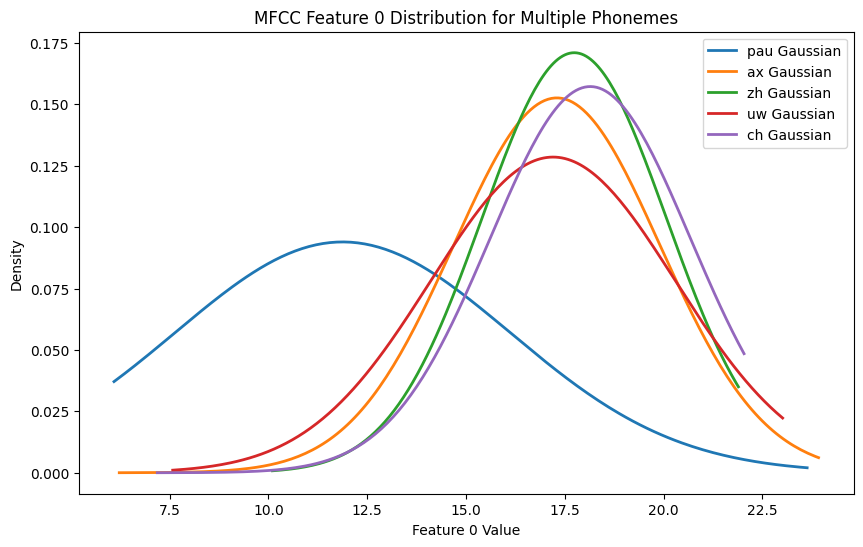

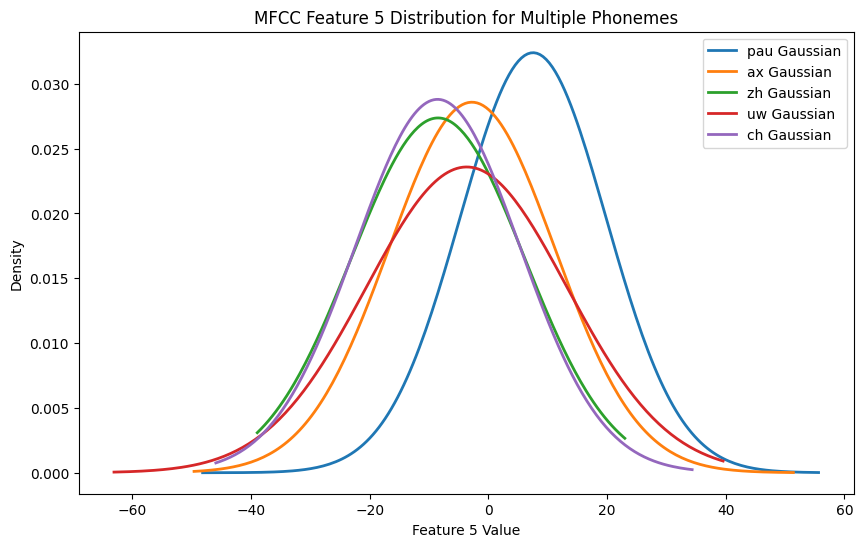

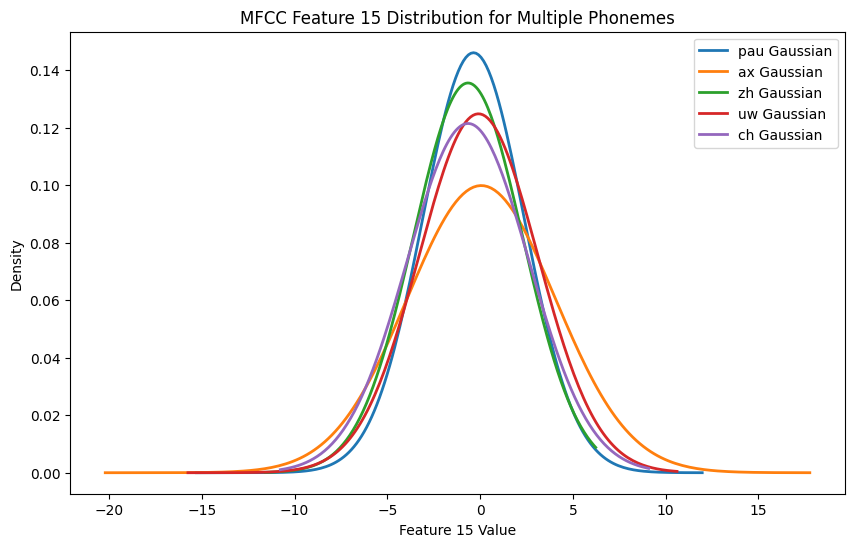

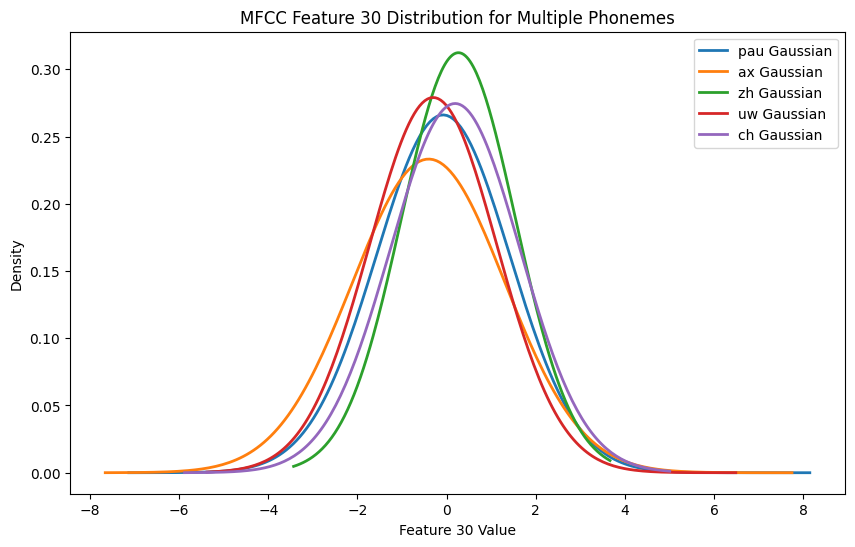

In [403]:
emission_parameters = {}

for phoneme_idx in range(len(phoneme_set)):
    # Go through training samples
    features_list = []
    for features, labels in train_data:
        # Masking once per audio file
        mask = labels == phoneme_idx
        phoneme_features = features[mask]

        if len(phoneme_features) > 0:
            features_list.append(phoneme_features)

    if len(features_list) > 0:
        all_features = np.vstack(features_list)

        mean = np.mean(all_features, axis=0)

        cov = np.cov(all_features, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6

        emission_parameters[phoneme_idx] = {"mean": mean, "cov": cov}


# Printing / visualising the results
print("Emission parameters mean: ", emission_parameters[0]["mean"].shape)
print("Full coveriance matrix: ", emission_parameters[0]["cov"].shape)

# Plotting 1D of the Gaussian (hard to do 39 dimensions)
features = []

for X, labels in train_data:
    mask = labels == phoneme_to_idx["aa"]
    features.append(X[mask])

features = np.vstack(features)

# show differences in learned distributions
phonemes_to_plot = ["pau", "ax", "zh", "uw", "ch"]  # select phonemes to visualize -> choose very different phonemes, and see difference!

# feature_idx = 0  # which MFCC feature to plot


# Index-range Type	      Meaning
# 0–12	      MFCC	      spectral shape
# 13–25	      delta	      speed of change
# 26–38	      delta-delta acceleration

for feature_idx in [0, 5, 15, 30]:  # [low MFCC, high MFCC, delta, delta-delta]

    plt.figure(figsize=(10, 6))

    for ph in phonemes_to_plot:
        ph_idx = phoneme_to_idx[ph]
        features_list = []
        for X, labels in train_data:
            mask = labels == ph_idx
            features_list.append(X[mask])
        features_arr = np.vstack(features_list)

        mean = emission_parameters[ph_idx]["mean"][feature_idx]
        std = np.sqrt(emission_parameters[ph_idx]["cov"][feature_idx, feature_idx])
        x = np.linspace(
            features_arr[:, feature_idx].min(), features_arr[:, feature_idx].max(), 200
        )

        plt.plot(x, norm.pdf(x, mean, std), label=f"{ph} Gaussian", linewidth=2)

    plt.title(f"MFCC Feature {feature_idx} Distribution for Multiple Phonemes")
    plt.xlabel(f"Feature {feature_idx} Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

From the MFCC plot we can see that most of the phonemes follow a similar Gaussian distribution, except for "pau".
Which means our model is capturing real acoustic differences in phonemes!

Also tells us that:
The features are meaningful.
The alignment is correct.
The emission model is learning something real.

Why each feature idx = dimension looks different: Because each dimension represents a completely different property of the sound. Different MFCC dimensions capture different aspects of speech.
Speech information is distributed across all 39 dimensions, and the model uses all of them together. So visualizing single dimensions doesn't show us the whole picture.

Delta and delta-delta (TODO: taka út seinna)
A trivial observation/interpretation of the delta and delta-delta features is that they approximate first and second derivatives of the signal. As estimates of the derivatives, they are not particularly accurate, but their simplicity probably makes up for that. The issue with accuracy is that differentiators tend to amplify white noise, whereas the desired signal remains unchanged. Consequently, the output is more noisy than the original signal. Differentiation is applied twice in the delta-delta feature such that issues with noise are also accumulated.
-- Which might explain why the Gaussian distributions become more drastically bell shaped the higher the delta or delta-delta values become.

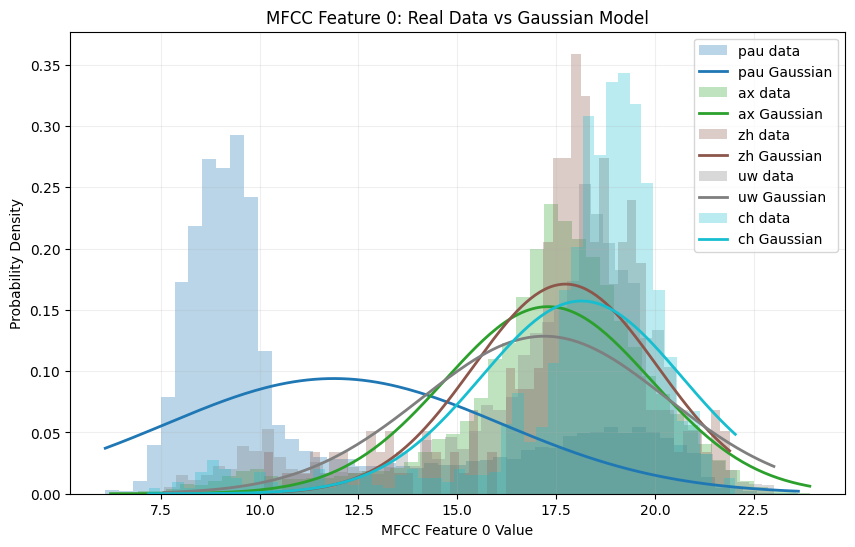

In [404]:
# REAL DATA VS GAUSSIAN MODEL
plt.figure(figsize=(10, 6))
feature_idx = 0

# Use a colormap for consistent colors
colors = plt.cm.tab10(np.linspace(0, 1, len(phonemes_to_plot)))

for i, ph in enumerate(phonemes_to_plot):
    ph_idx = phoneme_to_idx[ph]
    color = colors[i]

    features_list = []
    for X, labels in train_data:
        mask = labels == ph_idx
        features_list.append(X[mask])

    features_arr = np.vstack(features_list)

    # Histogram (real data)
    plt.hist(
        features_arr[:, feature_idx],
        bins=50,
        density=True,
        alpha=0.3,
        color=color,
        label=f"{ph} data",
    )

    # Gaussian (our model)
    mean = emission_parameters[ph_idx]["mean"][feature_idx]
    std = np.sqrt(emission_parameters[ph_idx]["cov"][feature_idx, feature_idx])

    x = np.linspace(
        features_arr[:, feature_idx].min(),
        features_arr[:, feature_idx].max(),
        200,
    )

    plt.plot(
        x,
        norm.pdf(x, mean, std),
        color=color,
        linewidth=2,
        label=f"{ph} Gaussian",
    )

# Labels and title
plt.xlabel(f"MFCC Feature {feature_idx} Value")
plt.ylabel("Probability Density")
plt.title(f"MFCC Feature {feature_idx}: Real Data vs Gaussian Model")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

From the plot above, we can see that our Gaussian distributions for specific phonemes follow the histogram of the real data but its not perfect.
Shows us that single Gaussian is not perfect for "pau", using multivariate Gaussian could be much more accurate.

We visualize the emission distributions by comparing the empirical distribution (histogram) of MFCC feature values for each phoneme 
with the corresponding Gaussian distribution learned by the HMM. 
Matching colors are used to associate each phoneme’s data with its modeled distribution. 
This allows us to assess how well our Gaussian assumption fits the observed data.

# Task 6.3 - Inference Algorithms 
# Inference: implement forward filtering (online posteriors) and Viterbi decoding (most likely state sequence).

Explanation...

Beliefs shape (one probability per phoneme per frame.): (279, 41)
Filtering accuracy on first training sample: 41.58%


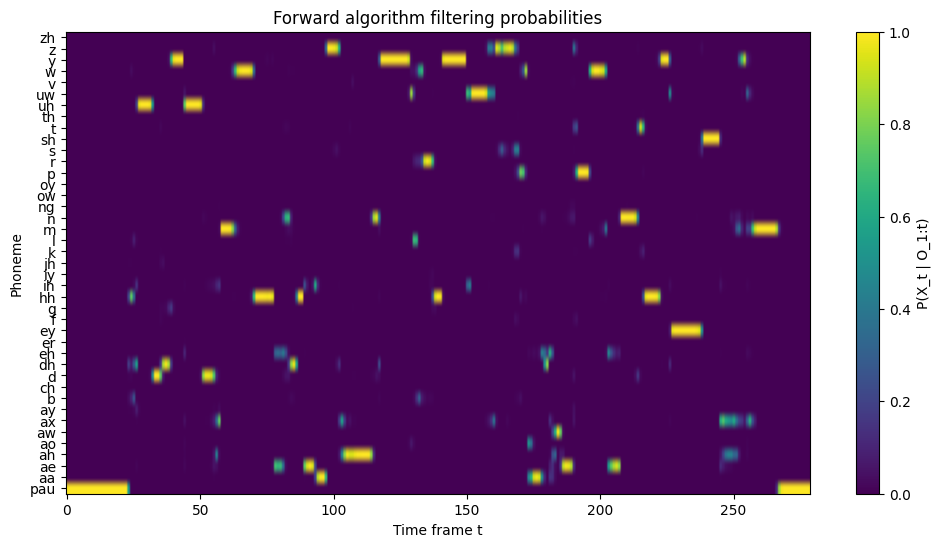

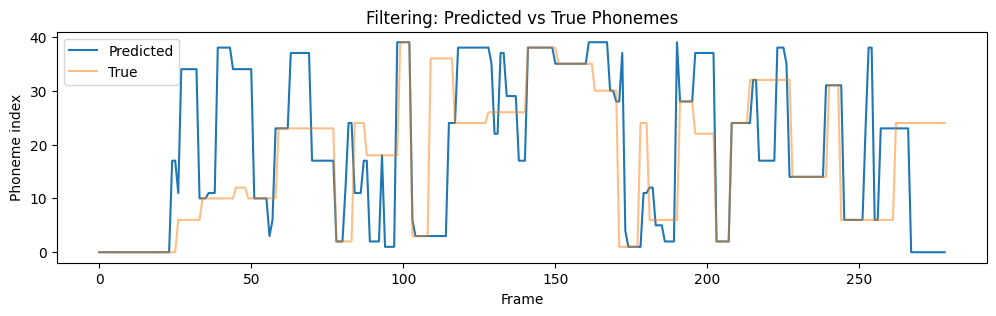

In [409]:
# Forward algorithm (filtering)
def forward_algorithm_vectorized(observations, initial_prob, transition_prob, emission_params):
    T, D = observations.shape
    N = len(initial_prob)

    # log emission probabilities
    log_emissions = np.zeros((T, N))
    for i in range(N):
        log_emissions[:, i] = multivariate_normal.logpdf(
            observations, mean=emission_params[i]["mean"], cov=emission_params[i]["cov"]
        )

    # log-alpha initialization
    log_alpha = np.zeros((T, N))
    log_alpha[0] = np.log(initial_prob + 1e-10) + log_emissions[0]

    # recursion using log-space sum (logaddexp) to prevent underflow
    for t in range(1, T):
        log_alpha[t] = log_emissions[t] + np.logaddexp.reduce(
            log_alpha[t - 1][:, np.newaxis] + np.log(transition_prob + 1e-10), axis=0
        )

    # normalized filtering beliefs
    beliefs = np.exp(log_alpha - log_alpha.max(axis=1, keepdims=True))
    beliefs /= beliefs.sum(axis=1, keepdims=True)
    return beliefs


# run forward algorithm on first training sample
features, labels = test_data[0]
beliefs = forward_algorithm_vectorized(features, pi, tran_matrix_A, emission_parameters)

print("Beliefs shape (one probability per phoneme per frame.):", beliefs.shape)

# Most likely phoneme per frame
predicted_phonemes = np.argmax(beliefs, axis=1)
accuracy = np.mean(predicted_phonemes == labels)
print(f"Filtering accuracy on first training sample: {accuracy*100:.2f}%")

# Plotting the filtering
phonemes = [
'pau','aa','ae','ah','ao','aw','ax','ay','b','ch','d','dh','eh','er','ey',
'f','g','hh','ih','iy','jh','k','l','m','n','ng','ow','oy','p','r','s','sh',
't','th','uh','uw','v','w','y','z','zh'
]

# plot 1
plt.figure(figsize=(12, 6))
plt.imshow(beliefs.T, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="P(X_t | O_1:t)")
plt.xlabel("Time frame t")
plt.yticks(range(len(phonemes)), phonemes)  
plt.ylabel("Phoneme")
plt.title("Forward algorithm filtering probabilities")
plt.show()

# plot 2
plt.figure(figsize=(12, 3))
plt.plot(predicted_phonemes, label="Predicted")
plt.plot(labels, alpha=0.5, label="True")
plt.xlabel("Frame")
plt.ylabel("Phoneme index")
plt.title("Filtering: Predicted vs True Phonemes")
plt.legend()
plt.show()


## Plot 1
## Why accuracy of the first training sample is low (~41%)
Filtering accuracy is expected to be low, especially with Gaussian emissions only.
Forward filtering gives frame-level posterior predictions.
HMM emissions are Gaussian based on raw MFCCs — these are not discriminative models.
We haven’t used Viterbi decoding yet, which finds the most likely sequence globally.
Frame-level argmax often underestimates accuracy because it ignores temporal smoothing (self-transitions are strong, but forward algorithm only gives marginals).

## Plot 2
Our model ...

Viterbi accuracy on first test sample: 32.97%


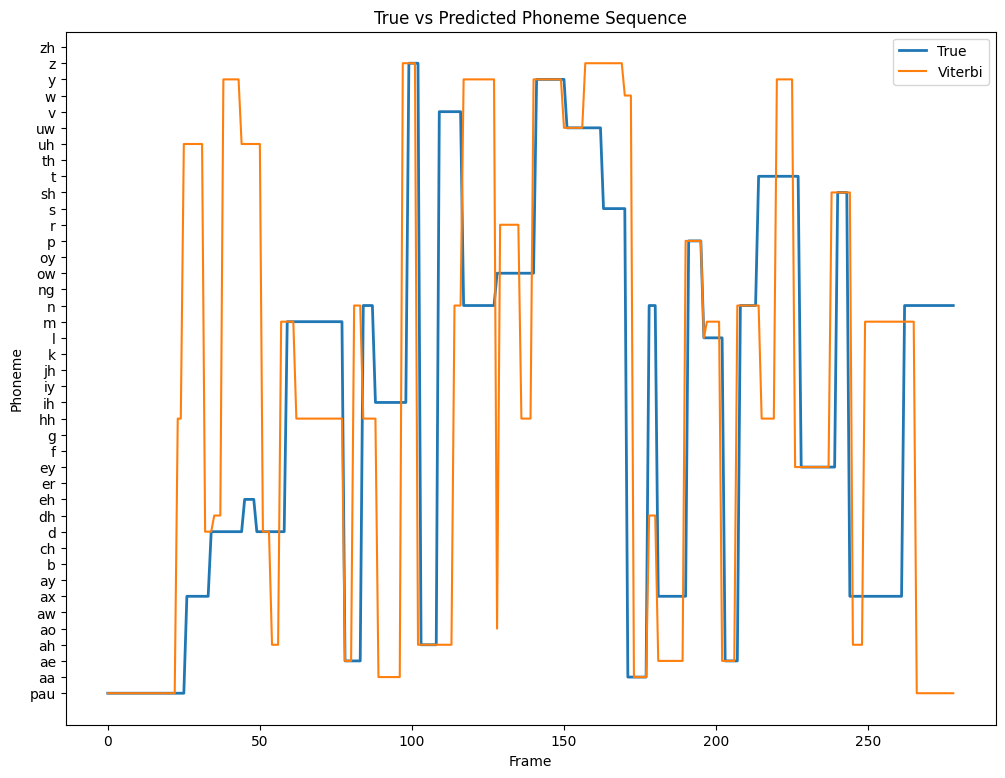

In [421]:
# TODO: are we decoding and correcting the error?
# FIXME: especially if Viterbi over-smooths sequences -> is it doing that?
def viterbi_log_fast(observations, initial_prob, transition_prob, emission_params):
    T, D = observations.shape
    N = len(initial_prob)

    log_pi = np.log(initial_prob + 1e-10)
    log_A = np.log(transition_prob + 1e-10)

    # Precompute emission log probabilities
    log_emissions = np.zeros((T, N))
    for j in range(N):
        log_emissions[:, j] = multivariate_normal.logpdf(
            observations,
            mean=emission_params[j]["mean"],
            cov=emission_params[j]["cov"]
        )

    log_delta = np.zeros((T, N))
    psi = np.zeros((T, N), dtype=int)

    # Initialization
    log_delta[0] = log_pi + log_emissions[0]

    # Recursion
    for t in range(1, T):
        for j in range(N):
            log_probs = log_delta[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(log_probs)
            log_delta[t, j] = np.max(log_probs) + log_emissions[t, j]

    # Backtrack - gives the most likely phoneme sequence across the entire audio clip
    best_path = np.zeros(T, dtype=int)
    best_path[-1] = np.argmax(log_delta[-1])

    for t in range(T-2, -1, -1):
        best_path[t] = psi[t+1, best_path[t+1]]

    return best_path


# Take one test sample
features, labels = test_data[0]

# Compute the most likely phoneme sequence
predicted_sequence = viterbi_log_fast(features, pi, tran_matrix_A, emission_parameters)

# Compare to ground truth
accuracy = np.mean(predicted_sequence == labels)
print(f"Viterbi accuracy on first test sample: {accuracy*100:.2f}%")

phonemes = [
'pau','aa','ae','ah','ao','aw','ax','ay','b','ch','d','dh','eh','er','ey',
'f','g','hh','ih','iy','jh','k','l','m','n','ng','ow','oy','p','r','s','sh',
't','th','uh','uw','v','w','y','z','zh'
]

# 0: 'pau', 1: 'aa', 2: 'ae', 3: 'ah', 4: 'ao', 5: 'aw', 6: 'ax',
# 7: 'ay', 8: 'b', 9: 'ch', 10: 'd', 11: 'dh', 12: 'eh', 13: 'er',
# 14: 'ey', 15: 'f', 16: 'g', 17: 'hh', 18: 'ih', 19: 'iy', 20: 'jh',
# 21: 'k', 22: 'l', 23: 'm', 24: 'n', 25: 'ng', 26: 'ow', 27: 'oy',
# 28: 'p', 29: 'r', 30: 's', 31: 'sh', 32: 't', 33: 'th',
# 34: 'uh', 35: 'uw', 36: 'v', 37: 'w', 38: 'y', 39: 'z', 40: 'zh'

# plot 1
plt.figure(figsize=(12, 9))
plt.plot(labels, label="True", linewidth=2)
plt.plot(predicted_sequence, label="Viterbi")
plt.title("True vs Predicted Phoneme Sequence")
plt.xlabel("Frame")
plt.yticks(range(len(phonemes)), phonemes)  
plt.ylabel("Phoneme")
plt.legend()
plt.show()

## Why accuracy is still low: 32.97%
Gaussian emission HMM is simple. Phonemes with similar MFCCs will often be confused.
No discriminative training (like NN or random forest) is used - generative HMMs are limited.

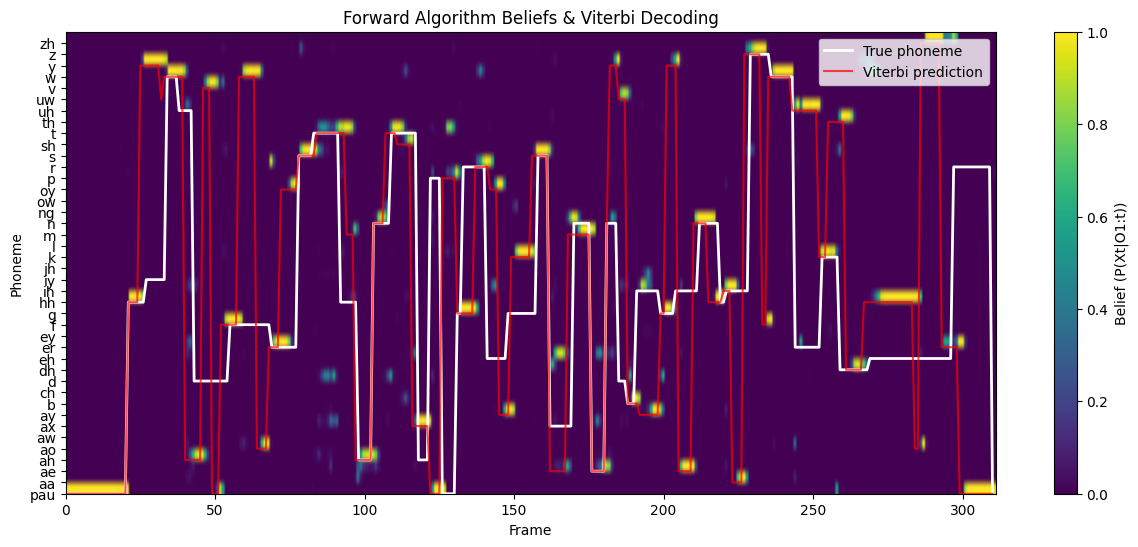

In [ ]:
# Take a test sample
features, labels = test_data[0] # TODO: have this as a part of the evaluation?
predicted_sequence = viterbi_log_fast(features, pi, tran_matrix_A, emission_parameters)

# Run forward algorithm to get beliefs
beliefs = forward_algorithm_vectorized(features, pi, tran_matrix_A, emission_parameters)

T, N = beliefs.shape

plt.figure(figsize=(15, 6))

# 1. Heatmap of beliefs
plt.imshow(
    beliefs.T, aspect="auto", origin="lower", cmap="viridis", extent=[0, T, 0, N]
)

# 2. True phoneme sequence
plt.plot(labels, color="white", linewidth=2, label="True phoneme")

# 3. Viterbi predicted sequence
plt.plot(
    predicted_sequence,
    color="red",
    linewidth=1.5,
    alpha=0.7,
    label="Viterbi prediction",
)

plt.yticks(range(N), phonemes)  # phoneme labels on y-axis
plt.xlabel("Frame")
plt.ylabel("Phoneme")
plt.title("Forward Algorithm Beliefs & Viterbi Decoding")
plt.colorbar(label="Belief (P(Xt|O1:t))")
plt.legend(loc="upper right")
plt.show()

Heatmap = probability distribution from the forward algorithm.
Bright areas → high probability for that phoneme at that frame.
Fuzzy areas → uncertainty between phonemes.

White line = ground truth.
Red line = Viterbi path — picks the most likely phoneme sequence from the heatmap.

You can see where the HMM is uncertain and how Viterbi “decides” in tricky parts.

In [431]:
# Optional!
# Task 6.4?
# Discriminative options: optionally replace Gaussian emissions with classifiers (e.g., random forest, NN).

# Use val.txt (optional) to tune hyperparameters or check for overfitting -> analyse!

# Overfitting - underfitting, relations between the model and the data. Are they compatible?


## Evaluation 

In [434]:
# For each utterance, predict phoneme sequences with Filtering and Viterbi decoding
# Viterbi is still performing worse than filtering (why???) FIXME:

# Storage lists
all_true = []
all_filter_pred = []
all_viterbi_pred = []

for features, labels in test_data:
    # Forward algorithm (filtering)
    beliefs = forward_algorithm_vectorized(
        features, pi, tran_matrix_A, emission_parameters
    )
    filter_pred = np.argmax(beliefs, axis=1)

    # Viterbi decoding
    viterbi_pred = viterbi_log_fast(features, pi, tran_matrix_A, emission_parameters)

    # Store
    all_true.append(labels)
    all_filter_pred.append(filter_pred)
    all_viterbi_pred.append(viterbi_pred)

# Concatenate all frames
all_true_flat = np.concatenate(all_true)
all_filter_flat = np.concatenate(all_filter_pred)
all_viterbi_flat = np.concatenate(all_viterbi_pred)

# Accuracy
filter_acc = np.mean(all_filter_flat == all_true_flat)
viterbi_acc = np.mean(all_viterbi_flat == all_true_flat)

print(f"Filtering accuracy (test set): {filter_acc*100:.2f}%")
print(f"Viterbi accuracy (test set): {viterbi_acc*100:.2f}%")

Filtering accuracy (test set): 33.65%
Viterbi accuracy (test set): 30.25%


Filtering accuracy (test set): 34.23%
Viterbi accuracy (test set): 30.77%


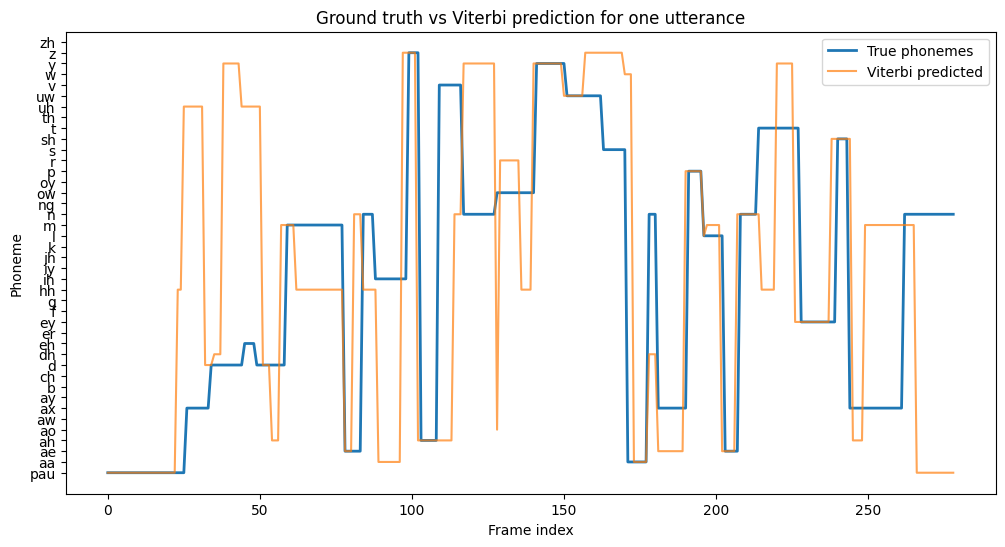

In [436]:
# Compare the predicted phoneme sequence with the ground truth label from the aligned label file
def evaluate_utterance(
    features, labels, initial_prob, transition_prob, emission_params, method="viterbi"
):
    """
    Predicts the phoneme sequence and compares it with ground truth labels.
    method: "viterbi" or "filtering"
    """
    if method == "viterbi":
        predicted = viterbi_log_fast(
            features, initial_prob, transition_prob, emission_params
        )
    elif method == "filtering":
        beliefs = forward_algorithm_vectorized(
            features, initial_prob, transition_prob, emission_params
        )
        predicted = np.argmax(beliefs, axis=1)
    else:
        raise ValueError("method must be 'viterbi' or 'filtering'")

    accuracy = np.mean(predicted == labels)
    return predicted, accuracy


filtering_accuracies = []
viterbi_accuracies = []

for features, labels in test_data:
    _, acc_f = evaluate_utterance(
        features, labels, pi, tran_matrix_A, emission_parameters, method="filtering"
    )
    _, acc_v = evaluate_utterance(
        features, labels, pi, tran_matrix_A, emission_parameters, method="viterbi"
    )

    filtering_accuracies.append(acc_f)
    viterbi_accuracies.append(acc_v)

print(f"Filtering accuracy (test set): {np.mean(filtering_accuracies)*100:.2f}%")
print(f"Viterbi accuracy (test set): {np.mean(viterbi_accuracies)*100:.2f}%")

features, labels = test_data[0]
pred_viterbi, _ = evaluate_utterance(
    features, labels, pi, tran_matrix_A, emission_parameters, method="viterbi"
)

plt.figure(figsize=(12, 6))
plt.plot(labels, label="True phonemes", linewidth=2)
plt.plot(pred_viterbi, label="Viterbi predicted", alpha=0.7)
plt.yticks(range(len(phoneme_set)), phoneme_set)
plt.xlabel("Frame index")
plt.ylabel("Phoneme")
plt.title("Ground truth vs Viterbi prediction for one utterance")
plt.legend()
plt.show()

In [444]:
# Report on the overall frame accuracy for both Filtering and Viterbi decoding one both the training and test data.

def compute_frame_accuracy(dataset, pi, tran_matrix_A, emission_parameters):
    """
    Compute overall frame-level accuracy for both Filtering and Viterbi.

    Args:
        dataset: list of (features, labels) tuples
        pi: initial probabilities
        tran_matrix_A: transition matrix
        emission_parameters: parameters for emission probabilities

    Returns:
        filter_acc, viterbi_acc
    """
    all_true = []
    all_filter_pred = []
    all_viterbi_pred = []

    for features, labels in dataset:
        # Filtering (forward algorithm)
        beliefs = forward_algorithm_vectorized(
            features, pi, tran_matrix_A, emission_parameters
        )
        filter_pred = np.argmax(beliefs, axis=1)

        # Viterbi decoding
        viterbi_pred = viterbi_log_fast(
            features, pi, tran_matrix_A, emission_parameters
        )

        # Store
        all_true.append(labels)
        all_filter_pred.append(filter_pred)
        all_viterbi_pred.append(viterbi_pred)

    # Concatenate all frames
    all_true_flat = np.concatenate(all_true)
    all_filter_flat = np.concatenate(all_filter_pred)
    all_viterbi_flat = np.concatenate(all_viterbi_pred)

    # Compute frame-level accuracy
    filter_acc = np.mean(all_filter_flat == all_true_flat)
    viterbi_acc = np.mean(all_viterbi_flat == all_true_flat)

    return filter_acc, viterbi_acc

# Training data accuracy
train_filter_acc, train_viterbi_acc = compute_frame_accuracy(
    train_data, pi, tran_matrix_A, emission_parameters
)

# Test data accuracy
test_filter_acc, test_viterbi_acc = compute_frame_accuracy(
    test_data, pi, tran_matrix_A, emission_parameters
)

print(f"Training set - Filtering accuracy: {train_filter_acc*100:.2f}%")
print(f"Training set - Viterbi accuracy:   {train_viterbi_acc*100:.2f}%")
print(f"Test set - Filtering accuracy:     {test_filter_acc*100:.2f}%")
print(f"Test set - Viterbi accuracy:       {test_viterbi_acc*100:.2f}%")

Training set - Filtering accuracy: 35.69%
Training set - Viterbi accuracy:   32.32%
Test set - Filtering accuracy:     33.65%
Test set - Viterbi accuracy:       30.25%


## The overall frame accuracy for both Filtering and Viterbi decoding one both the training and test data.
Training set - Filtering accuracy: 35.69%
Training set - Viterbi accuracy:   32.32%
Test set - Filtering accuracy:     33.65%
Test set - Viterbi accuracy:       30.25%

Training set performs better than the test set - to be expected since the model has trained on that data
Filtering accuracy is higher than the Viterbi accuracy - normal for frame-level accuracy

In [442]:
# For the test set, produce a confusion matrix over phonemes.
# TODO: missing

In [443]:
# For the test set, compute per-phoneme precision and recall.
# TODO: missing

# Analysis

1. How does the accuracy differ between Filtering and Viterbi? Why?
The accuracy is consistently better for Filtering rather than for Viterby.

2. Is the accuracy different between train and test set? Why?

3. Which phonemes are most often confused (e.g., similar vowels, stops, silence vs. fricatives)?

4. For which phonemes is the model better / worse at predicting them correctly?

5. Generally, how well does the approach work?

# TODO: plot some stuff for this! to "prove" the answers